In [1]:
# 更新 AtoB 的绘图框架，以便快速用于对比 sim 和 real 的数据
# 并能够批量化做参数寻找
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import scipy.io
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
folder_path = '../data/SimConstrastResults/AtoB_realsim_constrast_20250220020603'  # 替换为你的文件夹路径
folder_path = '../data/SimConstrastResults/AtoB_realsim_constrast_20250220151948'  # 替换为你的文件夹路径
npy_files = [f for f in os.listdir(folder_path) if f.endswith('.npz')]

data_list = []
for file_name in npy_files:
    file_path = os.path.join(folder_path, file_name)
    data = np.load(file_path)
    data_list.append(data)
    # print the c1, c2
    print(data['arr_0'])
    

[[ 7.60000000e+01  8.00000000e+01  1.00020000e+01 ... -7.39338419e-02
   5.13238409e-02  5.12093746e-02]
 [ 7.60000000e+01  8.00000000e+01  1.00030000e+01 ... -7.39501922e-02
   5.13180086e-02  5.12063036e-02]
 [ 7.60000000e+01  8.00000000e+01  1.00040000e+01 ... -7.39819773e-02
   5.13056280e-02  5.11996961e-02]
 ...
 [ 7.60000000e+01  8.00000000e+01  1.99980000e+01 ... -1.98971739e-01
   3.77255538e-02  3.76140048e-02]
 [ 7.60000000e+01  8.00000000e+01  1.99990000e+01 ... -1.98971739e-01
   3.77255538e-02  3.76140048e-02]
 [ 7.60000000e+01  8.00000000e+01  2.00000000e+01 ... -1.98971739e-01
   3.77255538e-02  3.76140048e-02]]
[[ 7.20000000e+01  7.20000000e+01  1.00020000e+01 ... -7.39338419e-02
   5.13238409e-02  5.12093746e-02]
 [ 7.20000000e+01  7.20000000e+01  1.00030000e+01 ... -7.39501922e-02
   5.13178767e-02  5.12061454e-02]
 [ 7.20000000e+01  7.20000000e+01  1.00040000e+01 ... -7.39820340e-02
   5.13052584e-02  5.11992203e-02]
 ...
 [ 7.20000000e+01  7.20000000e+01  1.9998000

In [ ]:
_ = data_list[120]['arr_0']
# print(_)
time_real = _[:,2]-10
theta1_real = (_[:,3]+math.pi/2)*180/np.pi
theta2_real = (_[:,4]+math.pi/2)*180/np.pi
plt.plot(time_real, theta1_real, label='theta1_real')
plt.plot(time_real, theta2_real, label='theta2_real')


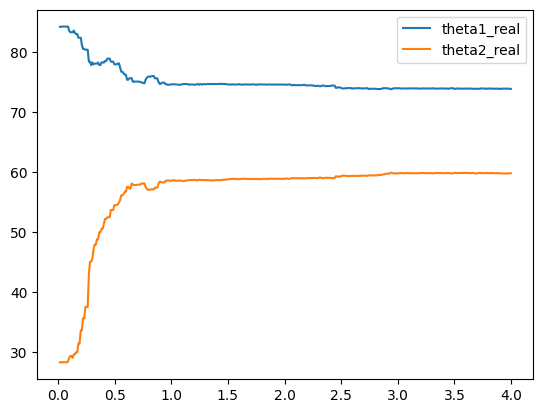

In [4]:
# Learn from the plotit
data = pd.read_csv('../data/Archive/A2Bdata/Dynamic_Group6_PartlyUsable_Static_2025-01-20_21-10-43_A2B_data.csv')    # Goup 3
# print(data.head())

time_real = data['relative_time'].values
theta1_real = data['thigh_theta21'].values
theta2_real = data['calf_theta32'].values
plt.plot(time_real, theta1_real, label='theta1_real')
plt.plot(time_real, theta2_real, label='theta2_real')

plt.legend()

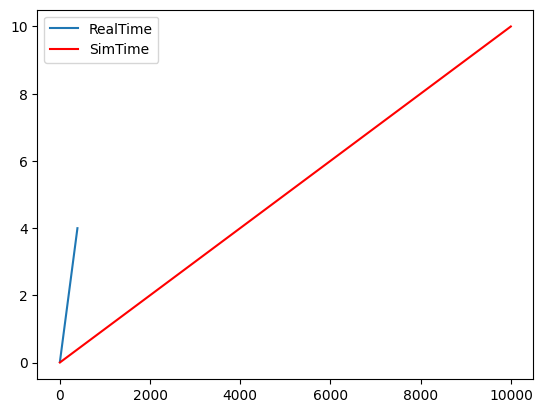

Text(0, 0.5, 'angle/rad')

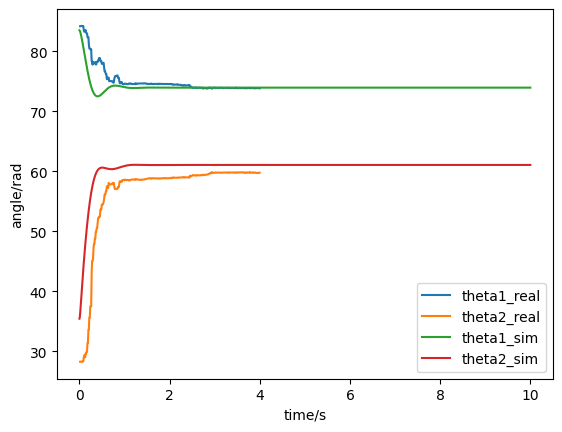

In [9]:
# real data
# t = scipy.io.loadmat("../AtoBMatlab/t.mat")['t']
# theta_1 = scipy.io.loadmat("../AtoBMatlab/theta_1.mat")['theta_1']
# theta_2 = scipy.io.loadmat("../AtoBMatlab/theta_2.mat")['theta_2']
t_real = time_real
theta1_real = theta1_real
theta2_real = theta2_real

# sim data
sim_data = data_list[-1]['arr_0']
t_sim = sim_data[:,2] - 10
theta1_sim = (sim_data[:,3]+math.pi/2)*180/math.pi
theta2_sim = (sim_data[:,4]+math.pi/2)*180/math.pi

# 创建图形和三维轴




# 时间并没有对齐
plt.plot(t_real, label="RealTime")
plt.plot(t_sim, 'r', label="SimTime")
plt.legend()
plt.show()

plt.plot(t_real, theta1_real, label="theta1_real")
plt.plot(t_real, theta2_real, label="theta2_real")

plt.plot(t_sim, theta1_sim, label="theta1_sim")
plt.plot(t_sim, theta2_sim, label="theta2_sim")

plt.legend()
plt.xlabel("time/s")
plt.ylabel("angle/rad")
# plt.xlim([0, 3])
# plt.ylim([0, 1.62])



In [ ]:

# cal the MSE: 需要使用插值计算： 考虑[0-4s]区间
t_intervel = np.linspace(0, 4, 300)
theta1_sim_intervel = np.interp(t_intervel, t_sim, theta1_sim)
theta2_sim_intervel = np.interp(t_intervel, t_sim, theta2_sim)
theta1_real_intervel = np.interp(t_intervel, t_real, theta1_real)
theta2_real_intervel = np.interp(t_intervel, t_real, theta2_real)

mse_theta1 = np.mean(np.square(theta1_sim_intervel-theta1_real_intervel))
mse_theta2 = np.mean(np.square(theta2_sim_intervel-theta2_real_intervel))
maxerror_theta1 = np.max(np.abs(theta1_sim_intervel-theta1_real_intervel))
maxerror_theta2 = np.max(np.abs(theta2_sim_intervel-theta2_real_intervel))

print(f"MSE_theta_1[0-4s]={mse_theta1}deg^2")
print(f"MaxError_theta_1[0-4s]={maxerror_theta1}deg")
print(f"MSE_theta_2[0-4s]={mse_theta2}deg^2")
print(f"MaxError_theta_2[0-4s]={maxerror_theta2}deg")


plt.text(2, 1.4, f"MSE_theta_1[0-4s]={round(mse_theta1, 6)}deg^2")
plt.text(2, 1.3, f"MaxError_theta_1[0-4s]={round(maxerror_theta1, 6)}deg")
plt.text(2, 0.6, f"MSE_theta_2[0-4s]={round(mse_theta2, 6)}deg^2")
plt.text(2, 0.5, f"MaxError_theta_2[0-4s]={round(maxerror_theta2, 6)}deg")

plt.title("Dynamic Test\n-Force Impulse(10N, 10N) at Static State(pi/2, 0)")
plt.show()


error: (np.float64(3.721873659312828), np.float64(23.33095867608293), np.float64(6.368436372057985), np.float64(19.08619232940688))
error: (np.float64(3.9033723822807684), np.float64(25.55334367405438), np.float64(6.5007280320781575), np.float64(19.84242681409084))
error: (np.float64(4.0927928484684735), np.float64(29.287036907548476), np.float64(6.687754421865833), np.float64(21.099241048450704))
error: (np.float64(4.289466061512233), np.float64(32.42263857990824), np.float64(6.880548578338036), np.float64(22.16127183688567))
error: (np.float64(4.4846987522507105), np.float64(37.81445120412767), np.float64(7.0890050904578885), np.float64(24.028103379145524))
error: (np.float64(5.015646921324625), np.float64(27.887969596139264), np.float64(7.458893868725525), np.float64(20.66981002470015))
error: (np.float64(5.01287882937736), np.float64(28.952988615648337), np.float64(7.457271025435446), np.float64(21.012572388954407))
error: (np.float64(4.757864191372759), np.float64(25.4602424940815

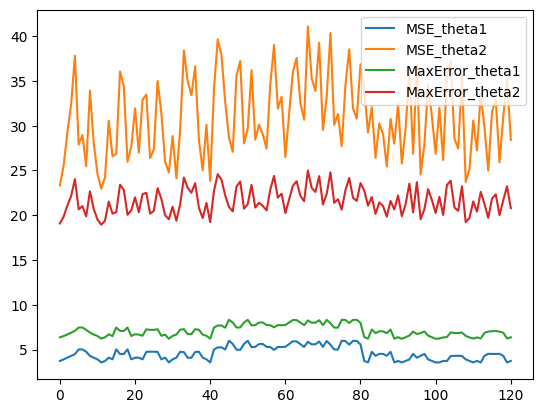

In [7]:
def cal_error(t_sim, theta1_sim, theta2_sim):
    t_intervel = np.linspace(0, 4, 300)
    theta1_sim_intervel = np.interp(t_intervel, t_sim, theta1_sim)
    theta2_sim_intervel = np.interp(t_intervel, t_sim, theta2_sim)
    theta1_real_intervel = np.interp(t_intervel, t_real, theta1_real)
    theta2_real_intervel = np.interp(t_intervel, t_real, theta2_real)

    mse_theta1 = np.mean(np.square(theta1_sim_intervel-theta1_real_intervel))
    mse_theta2 = np.mean(np.square(theta2_sim_intervel-theta2_real_intervel))
    maxerror_theta1 = np.max(np.abs(theta1_sim_intervel-theta1_real_intervel))
    maxerror_theta2 = np.max(np.abs(theta2_sim_intervel-theta2_real_intervel))
    # plt.plot(t_intervel, theta1_sim_intervel, label='theta1_sim')
    # plt.plot(t_intervel, theta2_sim_intervel, label='theta2_sim')
    # plt.plot(t_intervel, theta1_real_intervel, label='theta1_real')
    # plt.plot(t_intervel, theta2_real_intervel, label='theta2_real')
    # legend = plt.legend()
    # plt.show()

    # print(f"MSE_theta_1[0-4s]={mse_theta1}deg^2")
    # print(f"MaxError_theta_1[0-4s]={maxerror_theta1}deg")
    # print(f"MSE_theta_2[0-4s]={mse_theta2}deg^2")
    # print(f"MaxError_theta_2[0-4s]={maxerror_theta2}deg")
    return mse_theta1, mse_theta2, maxerror_theta1, maxerror_theta2

Error_array = []
for data in data_list:
    _ = data['arr_0']
    time_sim = _[:,2]-10
    theta1_sim = (_[:,3]+math.pi/2)*180/np.pi
    theta2_sim = (_[:,4]+math.pi/2)*180/np.pi
    # plt.plot(time_sim, theta1_sim, label='theta1_sim')
    # plt.plot(time_sim, theta2_sim, label='theta2_sim')
    # plt.plot(time_real, theta1_real, label='theta1_real')
    # plt.plot(time_real, theta2_real, label='theta2_real')
    # plt.show()
    error = cal_error(time_sim, theta1_sim, theta2_sim)
    Error_array.append(error)
    print("error:", error)

# 绘制误差图
Error_array = np.array(Error_array)
plt.plot(Error_array[:,0], label="MSE_theta1")
plt.plot(Error_array[:,1], label="MSE_theta2")
plt.plot(Error_array[:,2], label="MaxError_theta1")
plt.plot(Error_array[:,3], label="MaxError_theta2")
plt.legend()

# 寻找：MaxError_theta1<5deg
for i, error in enumerate(Error_array):
    print(error)
    if error[2] < 5 and error[3] < 5:
        print(f"Find the MaxError_theta1<5deg at {i}")
        break

